## Понижение размерности

### Классная работа

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_blobs, make_circles
from sklearn.datasets import fetch_covtype
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.utils import resample
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

#### PCA сгенерированных данных

In [2]:
n_samples = 100
x = np.random.normal(0, 1, n_samples)  # Первый признак
y = 2 * x + np.random.normal(0, 0.5, n_samples)  # Второй признак (коррелирован с первым)

X = np.column_stack((x, y))

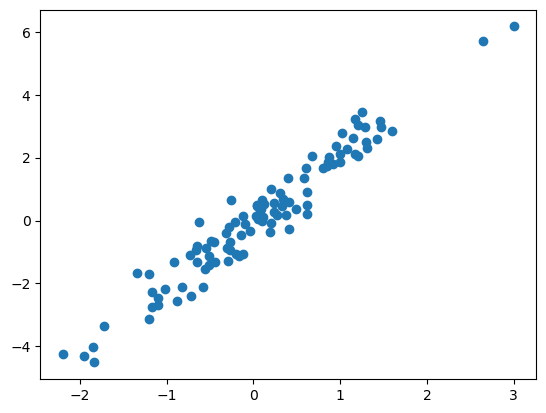

In [3]:
plt.scatter(x,y)

In [4]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

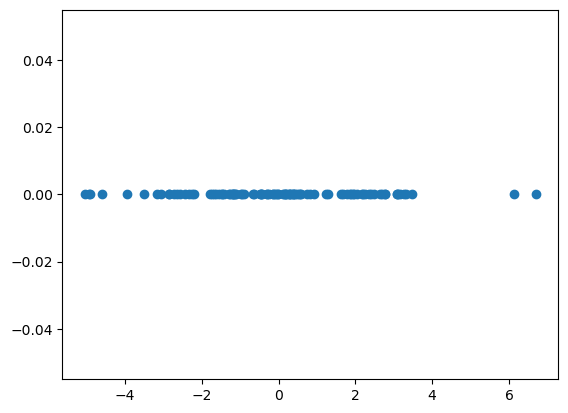

In [5]:
y_zeros = np.zeros_like(X_pca)
plt.scatter(X_pca, y=y_zeros)

In [6]:
print(f"Главная компонента (направление): {pca.components_}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")

Главная компонента (направление): [[0.41463793 0.90998648]]
Объясненная дисперсия: [0.9913097]


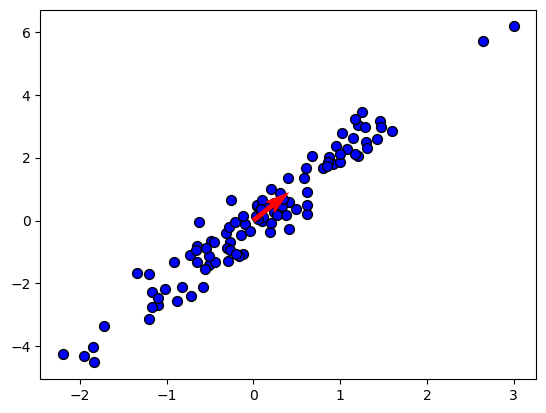

In [7]:
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
pc1_direction = pca.components_[0]
plt.quiver(0, 0, pc1_direction[0], pc1_direction[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

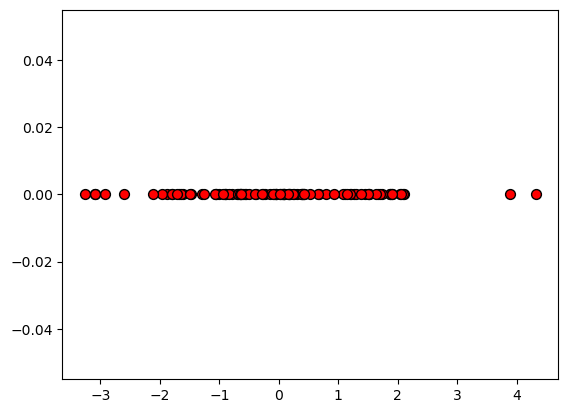

In [9]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca, np.zeros_like(X_pca), c='red', edgecolor='k', s=50)

#### PCA на многомерных данных

In [10]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
X.shape

(569, 30)

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)  # Уменьшаем до 2 компонент
X_pca = pca.fit_transform(X_scaled)

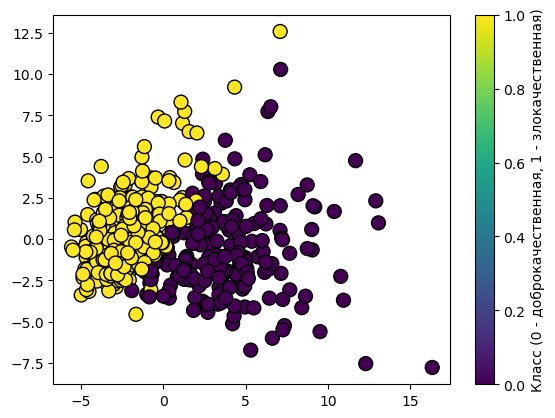

In [12]:
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolors='black', s=100)
cbar = plt.colorbar(scatter)
cbar.set_label('Класс (0 - доброкачественная, 1 - злокачественная)')

*> Если вы задаетесь вопросом, что именно отложено по осям, то ответ может вас разочаровать - главные компоненты. Никакого предметного смысла они не несут.*



In [13]:
print(f"Главная компонента (направление): {pca.components_}")

Главная компонента (направление): [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


In [14]:
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182]
Суммарная объясненная дисперсия: 0.63


#### Метод локтя для PCA

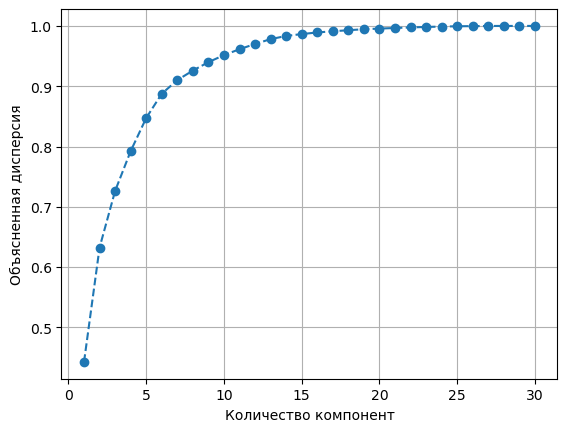

In [15]:
n_components_range = range(1, 31)
explained_variance = []
for n in n_components_range:
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance.append(sum(pca.explained_variance_ratio_))

plt.plot(n_components_range, explained_variance, marker='o', linestyle='--')
plt.xlabel('Количество компонент')
plt.ylabel('Объясненная дисперсия')
plt.grid(True)

In [16]:
pca = PCA(n_components=7)  # Уменьшаем до 7 компонент
X_pca = pca.fit_transform(X_scaled)

# Объясненная дисперсия
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734]
Суммарная объясненная дисперсия: 0.91


#### Метод LDA

In [17]:
n_samples = 100

x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

Text(0, 0.5, 'Признак 2')

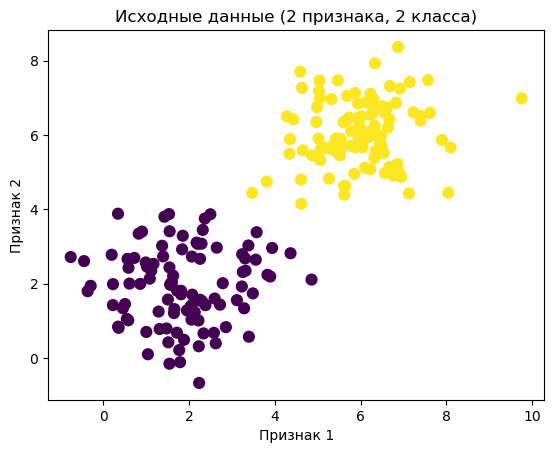

In [18]:
plt.scatter(X[:,0], X[:,1], c=y, s=60)
plt.title("Исходные данные (2 признака, 2 класса)")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

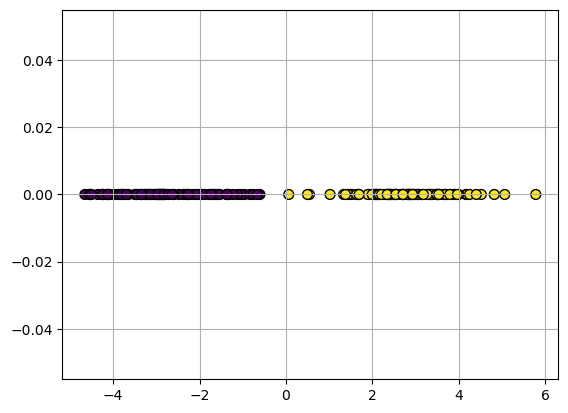

In [20]:
plt.scatter(X_lda, np.zeros_like(X_lda), c=y, edgecolor='k', s=50)
plt.grid(True)

In [21]:
print(f"Коэффициенты LDA: {lda.coef_}")

Коэффициенты LDA: [[7.91908818 9.52420874]]


In [22]:
print(f"Коэффициенты LDA: {lda.coef_}")

Коэффициенты LDA: [[7.91908818 9.52420874]]


#### Метод LDA для анизатропных классов

In [23]:
X, y = make_blobs(n_samples=200, random_state=170, centers=2)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(X, transformation)

<module 'matplotlib.pyplot' from 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

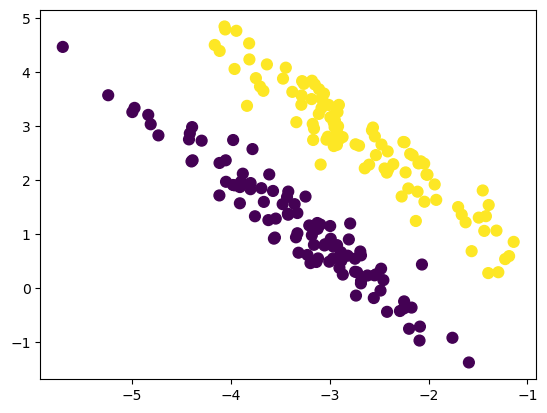

In [24]:
plt.scatter(X[:,0], X[:,1], c=y, s=60)
plt

In [25]:
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)

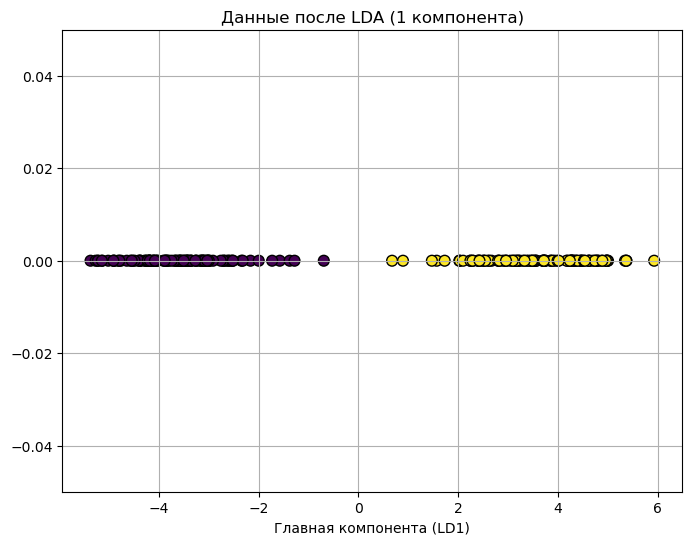

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='viridis', edgecolors='black', s=60)
plt.title("Данные после LDA (1 компонента)")
plt.xlabel("Главная компонента (LD1)")
plt.ylim(-0.05, 0.05)
plt.grid(True)
plt.show()

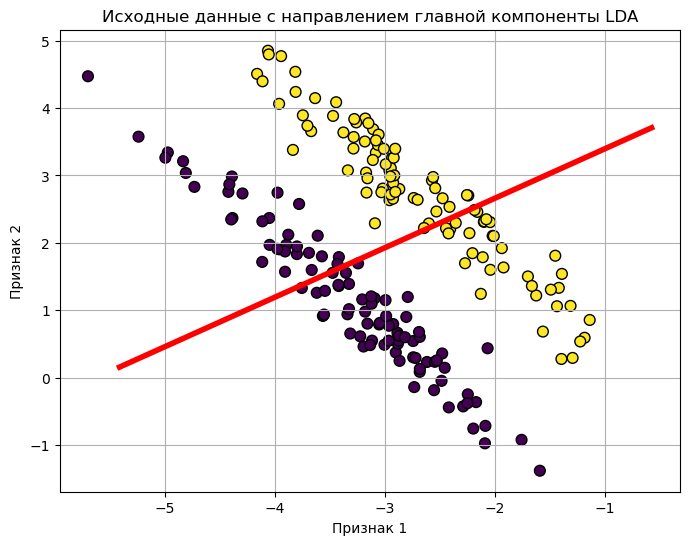

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='black', s=60)
lda_dir = lda.scalings_[:, 0]
w_lda = lda_dir / np.linalg.norm(lda_dir)

center = X.mean(axis=0)
t = np.linspace(-3, 3, 100)
plt.plot(center[0] + t * w_lda[0], center[1] + t * w_lda[1], color='red', linewidth=4)

plt.title("Исходные данные с направлением главной компоненты LDA")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.grid(True)
plt.show()

In [28]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

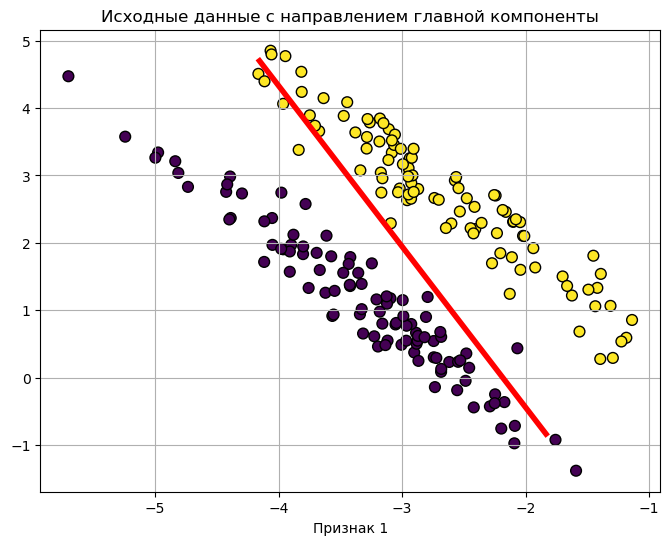

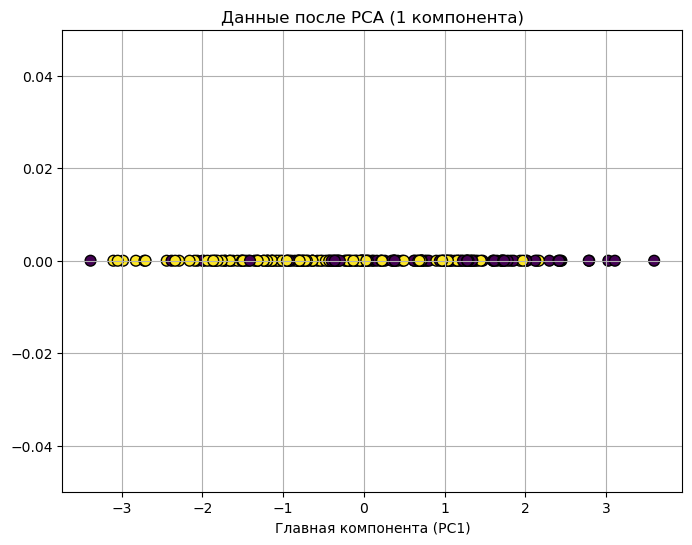

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='black', s=60)
pca_dir = pca.components_[0]
t = np.linspace(-3, 3, 100)
plt.plot(center[0] + t * pca_dir[0], center[1] + t * pca_dir[1], color='red', linewidth=4)

plt.title("Исходные данные с направлением главной компоненты")
plt.xlabel("Признак 1")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_pca, np.zeros_like(X_pca), c=y, cmap='viridis', edgecolors='black', s=60)
plt.title("Данные после PCA (1 компонента)")
plt.xlabel("Главная компонента (PC1)")
plt.ylim(-0.05, 0.05)
plt.grid(True)
plt.show()

#### Метод t-SNE

In [30]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=1, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

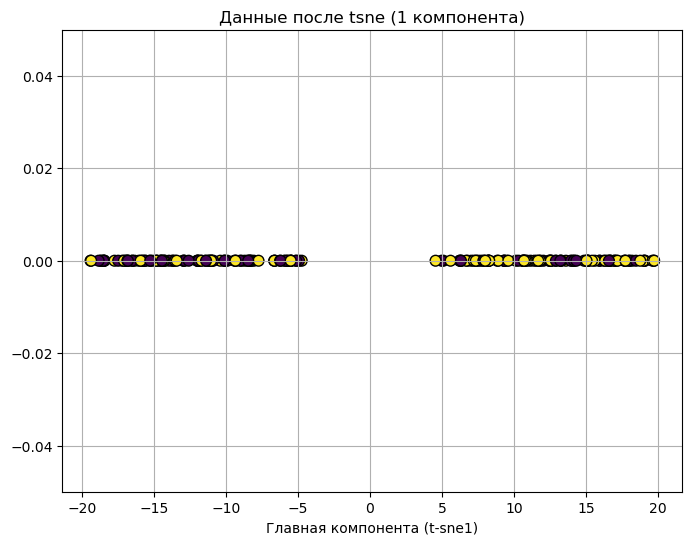

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne, np.zeros_like(X_tsne), c=y, cmap='viridis', edgecolors='black', s=60)
plt.title("Данные после tsne (1 компонента)")
plt.xlabel("Главная компонента (t-sne1)")
plt.ylim(-0.05, 0.05)
plt.grid(True)
plt.show()

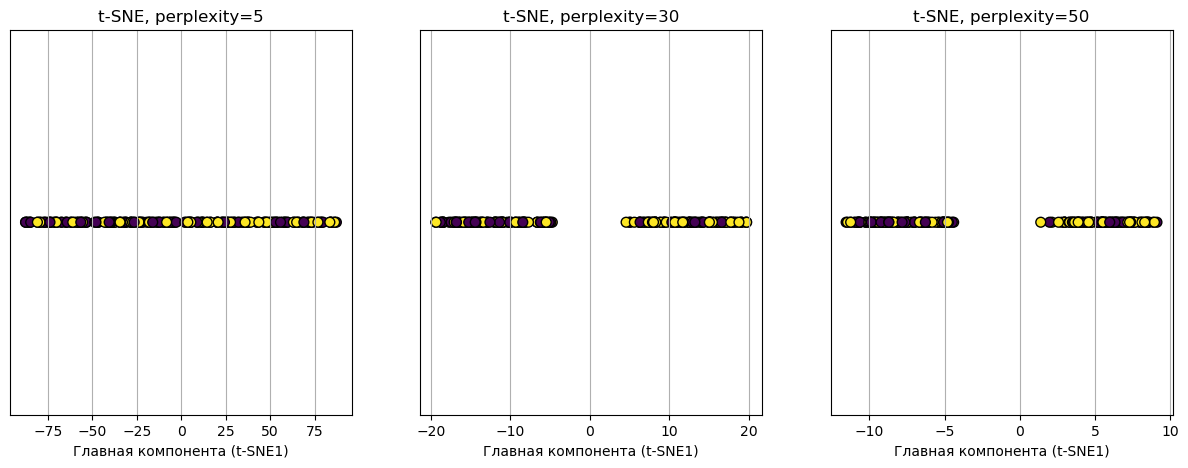

In [32]:
perplexity_values = [5, 30, 50]
plt.figure(figsize=(15, 5))
for i, perplexity in enumerate(perplexity_values):
    tsne = TSNE(n_components=1, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_tsne, np.zeros_like(X_tsne), c=y, cmap='viridis', edgecolor='k', s=50)
    plt.title(f't-SNE, perplexity={perplexity}')
    plt.xlabel('Главная компонента (t-SNE1)')
    plt.yticks([])
    plt.grid(True)

#### Kernel PCA для нелинейных данных

In [33]:
X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

Text(0.5, 1.0, 'Исходные данные')

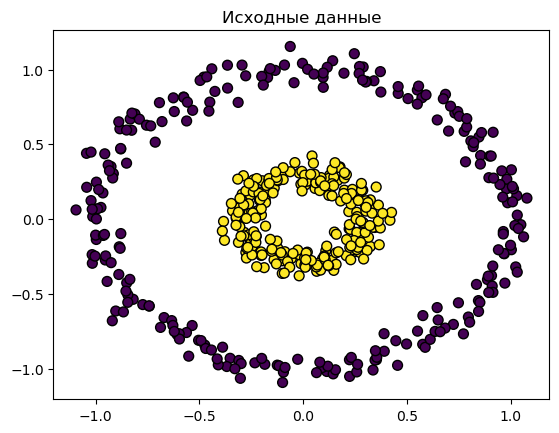

In [34]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.title("Исходные данные")

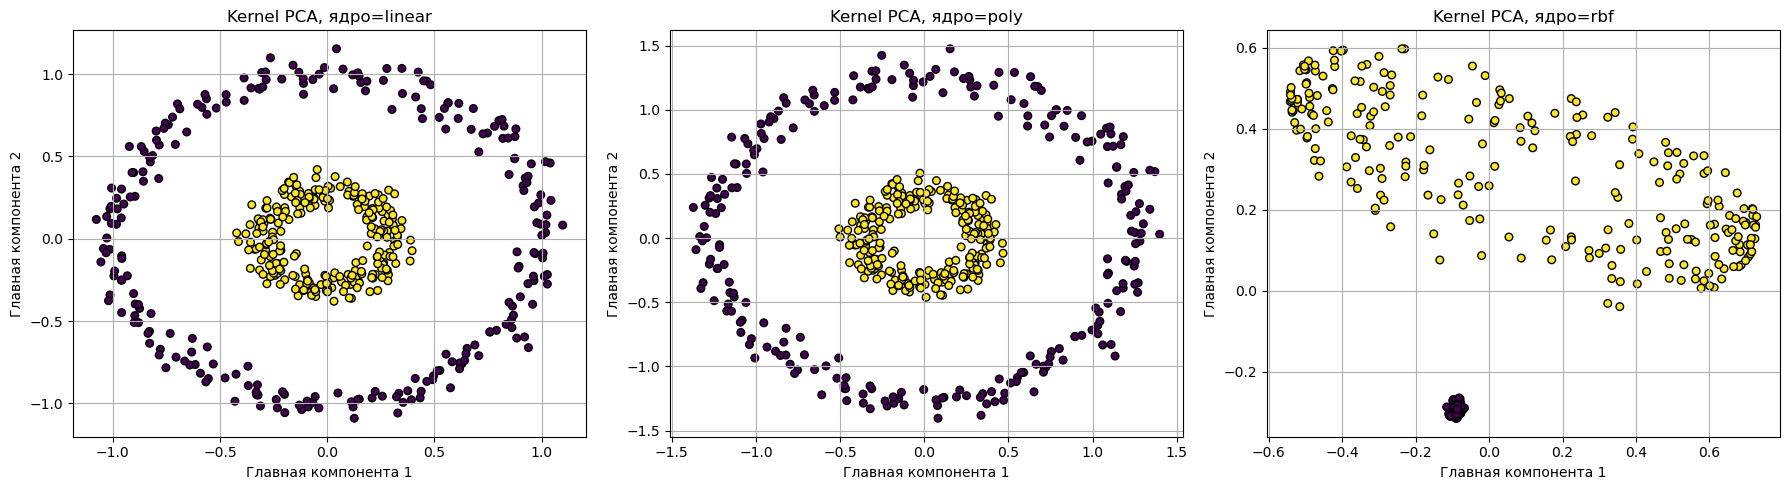

In [35]:
kernels = ['linear', 'poly', 'rbf']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, kernels):
    gamma_val = 10 if kernel == 'rbf' else None
    kpca = KernelPCA(n_components=2, kernel=kernel, gamma=gamma_val)
    X_kpca = kpca.fit_transform(X)

    ax.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis', edgecolors='black', s=30)
    ax.set_title(f"Kernel PCA, ядро={kernel}")
    ax.set_xlabel("Главная компонента 1")
    ax.set_ylabel("Главная компонента 2")
    ax.grid(True)

plt.tight_layout()
plt.show()

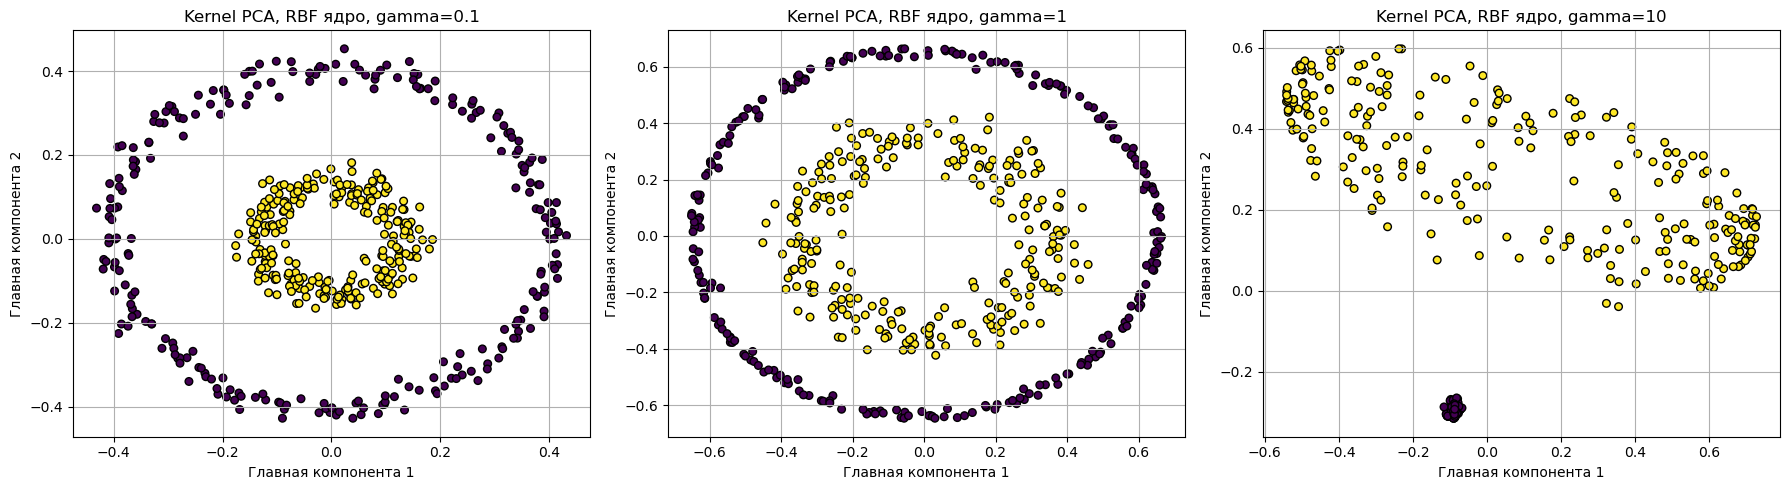

In [36]:
gamma_values = [0.1, 1, 10]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, gamma in zip(axes, gamma_values):
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma)
    X_kpca = kpca.fit_transform(X)

    ax.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis', edgecolors='black', s=30)
    ax.set_title(f"Kernel PCA, RBF ядро, gamma={gamma}")
    ax.set_xlabel("Главная компонента 1")
    ax.set_ylabel("Главная компонента 2")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Задания для самостиятельного выполнения

#### 1. Попробуйте изменить уровень шума в данных (например, увеличить или уменьшить шум в y) и посмотрите, как это влияет на результат PCA.

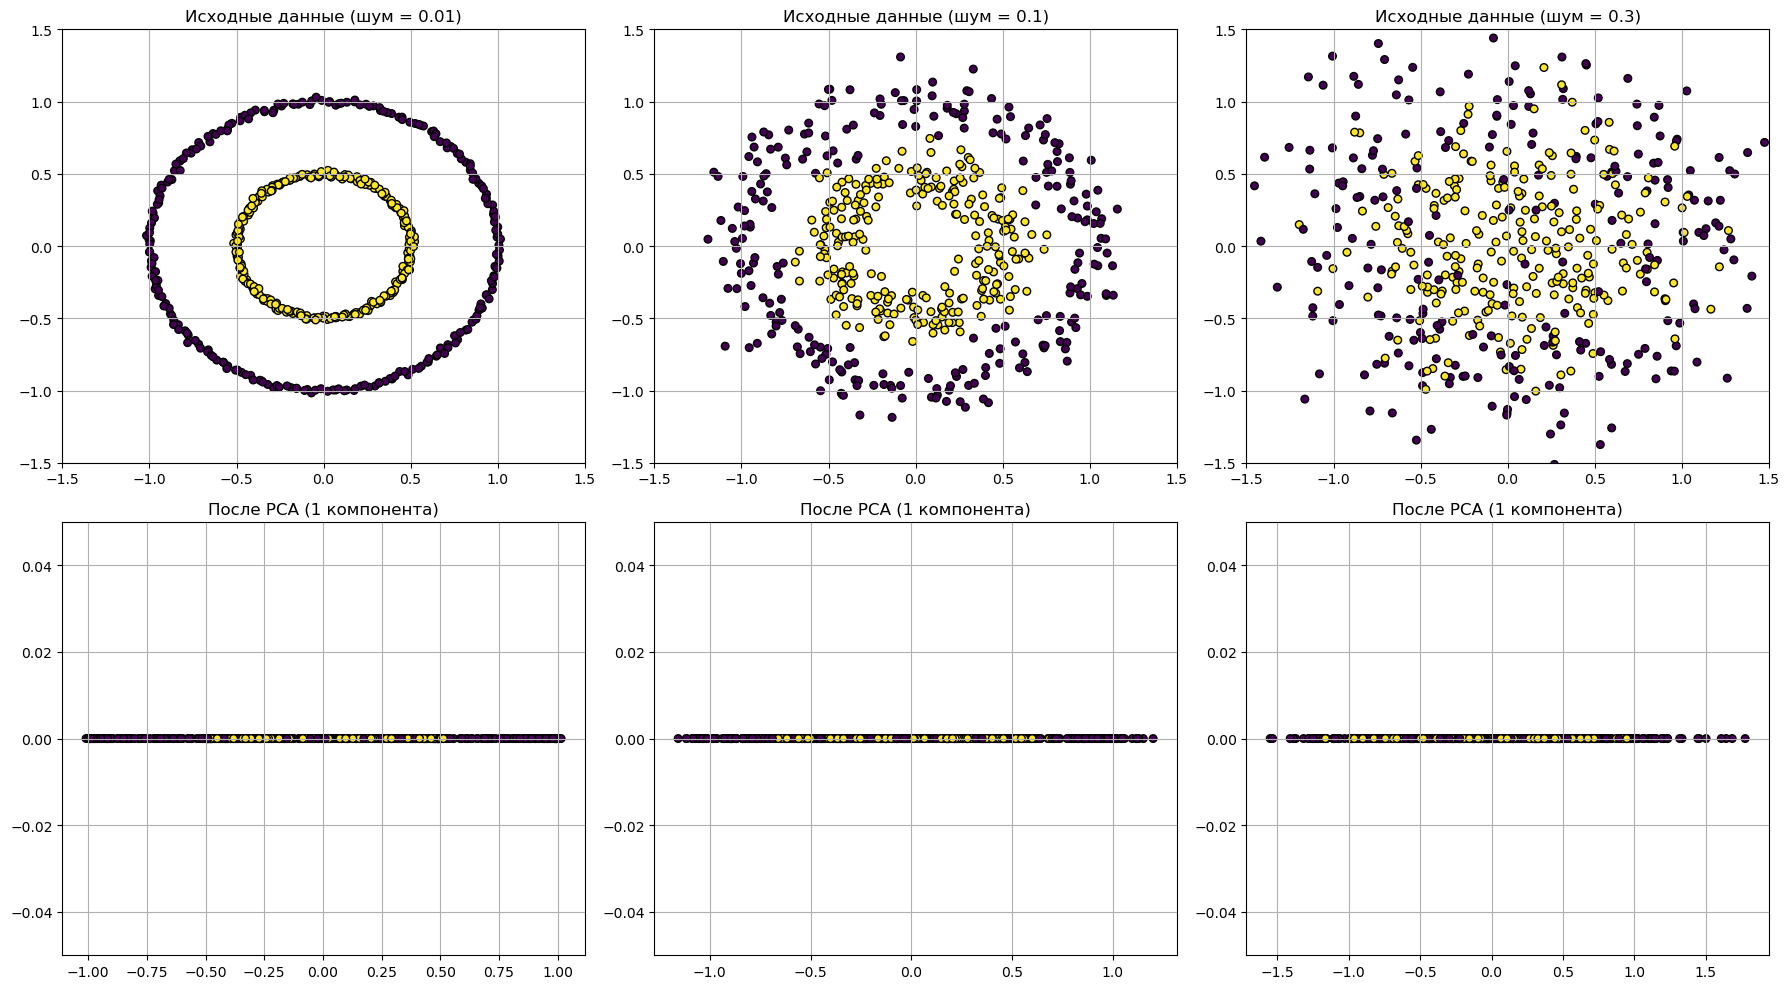

In [37]:
noise = [0.01, 0.1, 0.3]
fig, axes = plt.subplots(2, len(noise), figsize=(18, 10))
for i, n in enumerate(noise):
    X, y = make_circles(n_samples=500, factor=0.5, noise=n, random_state=42)

    axes[0, i].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='black', s=30)
    axes[0, i].set_title(f"Исходные данные (шум = {n})")
    axes[0, i].grid(True)
    axes[0, i].set_xlim(-1.5, 1.5)
    axes[0, i].set_ylim(-1.5, 1.5)


    pca = PCA(n_components=1)
    X_pca = pca.fit_transform(X)

    axes[1, i].scatter(X_pca, np.zeros_like(X_pca), c=y, cmap='viridis', edgecolors='black', s=30)
    axes[1, i].set_title(f"После PCA (1 компонента)")
    axes[1, i].grid(True)
    axes[1, i].set_ylim(-0.05, 0.05)

plt.tight_layout()
plt.show()

#### 2. Добавьте третий признак, который также коррелирует с первыми двумя, и примените PCA с n_components=2.

In [38]:
n_samples = 100
np.random.seed(42)

In [39]:
x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

In [40]:
X_2d = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

In [41]:
noise = np.random.normal(0, 0.3, size=X_2d.shape[0])
feature_3 = (X_2d[:, 0] + X_2d[:, 1]) / 2 + noise
X_3d = np.column_stack((X_2d, feature_3))

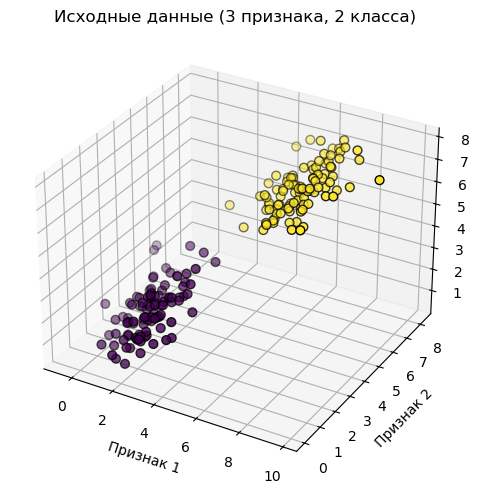

In [47]:
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y, cmap='viridis', edgecolors='black', s=40)
ax1.set_title("Исходные данные (3 признака, 2 класса)")
ax1.set_xlabel("Признак 1")
ax1.set_ylabel("Признак 2")
ax1.set_zlabel("Признак 3")

plt.tight_layout()
plt.show()

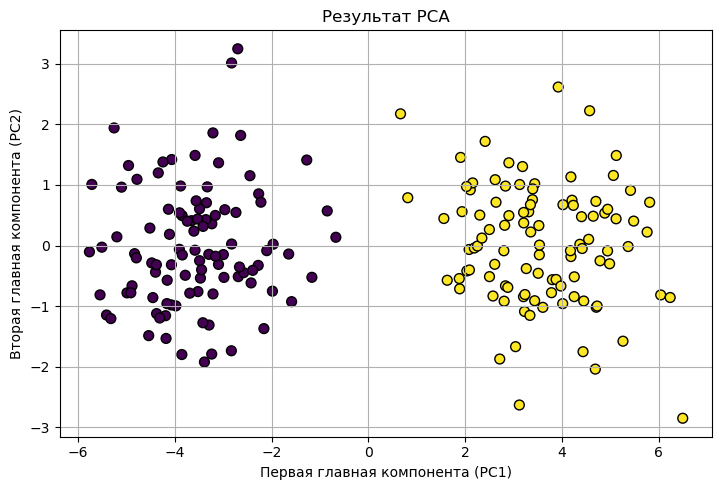

In [48]:
fig = plt.figure(figsize=(14, 5))

pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_3d)

ax2 = fig.add_subplot(122)
scatter2 = ax2.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='viridis', edgecolors='black', s=50)
ax2.set_title("Результат PCA")
ax2.set_xlabel("Первая главная компонента (PC1)")
ax2.set_ylabel("Вторая главная компонента (PC2)")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [43]:
print(f"Доля дисперсии, сохраненная PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Доля дисперсии, сохраненная PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Суммарно сохранено информации: {sum(pca.explained_variance_ratio_):.2%}")

Доля дисперсии, сохраненная PC1: 93.17%
Доля дисперсии, сохраненная PC2: 6.46%
Суммарно сохранено информации: 99.62%


### 3. Попробуйте изменить расположение классов (например, сделать их ближе друг к другу) и посмотрите, как это влияет на результат LDA.

In [49]:
X, y = make_blobs(n_samples=200, random_state=170, centers=2, cluster_std=1.2)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_shifted = np.dot(X, transformation)
X_shifted[y == 1] += [1.0, -1.0]

In [50]:
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_shifted, y)

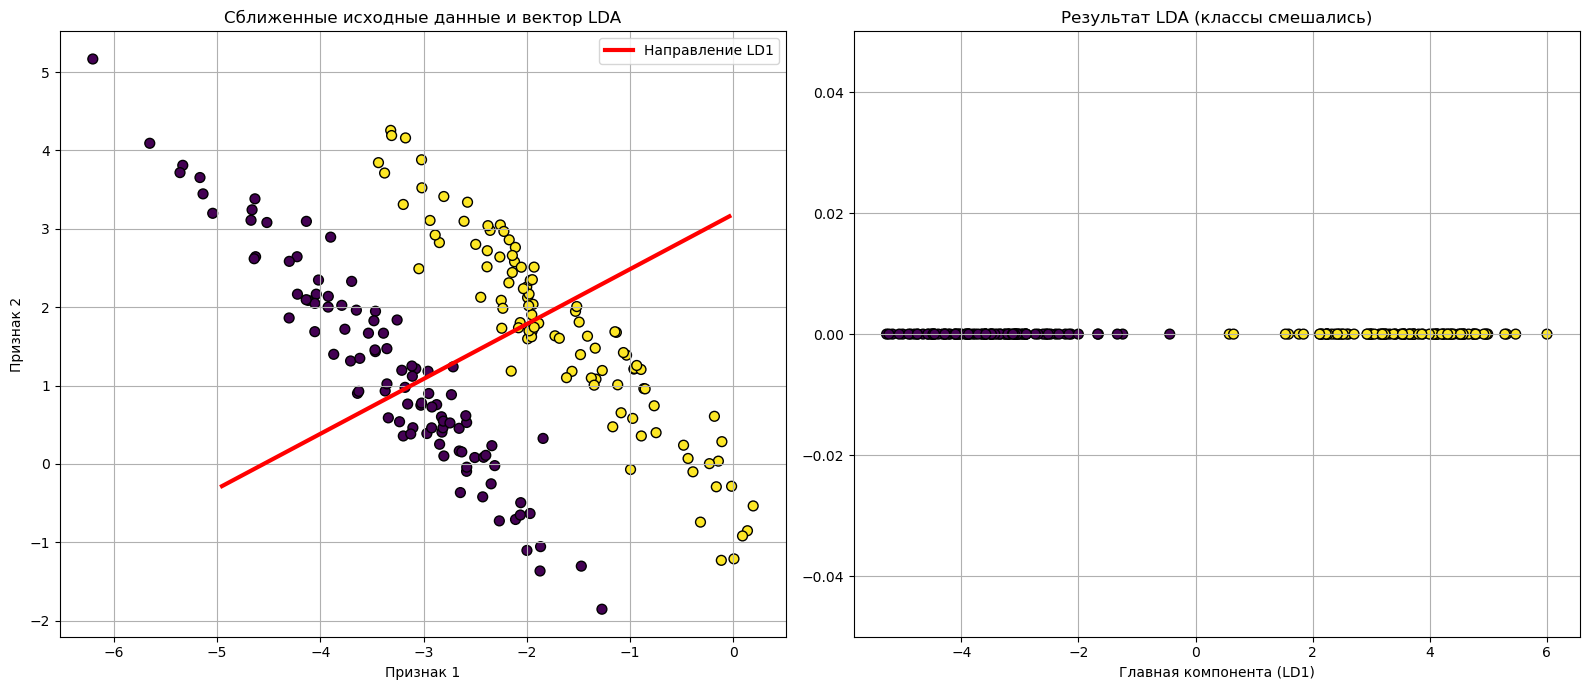

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(X_shifted[:, 0], X_shifted[:, 1], c=y, cmap='viridis', edgecolors='black', s=50)
lda_dir = lda.scalings_[:, 0]
w_lda = lda_dir / np.linalg.norm(lda_dir)
center = X_shifted.mean(axis=0)
t = np.linspace(-3, 3, 100)
axes[0].plot(center[0] + t * w_lda[0], center[1] + t * w_lda[1], color='red', linewidth=3, label='Направление LD1')

axes[0].set_title("Сближенные исходные данные и вектор LDA")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")
axes[0].grid(True)
axes[0].legend()

axes[1].scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='viridis', edgecolors='black', s=50)
axes[1].set_title("Результат LDA (классы смешались)")
axes[1].set_xlabel("Главная компонента (LD1)")
axes[1].set_ylim(-0.05, 0.05)
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### 4. Добавьте третий класс и примените LDA с n_components=2.

In [52]:
X, y = make_blobs(n_samples=300, random_state=42, centers=3, cluster_std=1.0)

lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y)

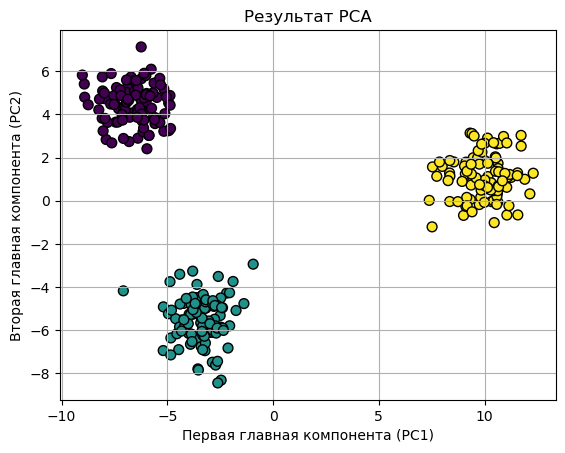

In [53]:
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='viridis', edgecolors='black', s=50)
plt.title("Результат PCA")
plt.xlabel("Первая главная компонента (PC1)")
plt.ylabel("Вторая главная компонента (PC2)")
plt.grid()

#### 5. Сравните LDA с PCA на этих же данных. Какой метод лучше разделяет классы?

In [54]:
X, y = make_blobs(n_samples=300, random_state=42, centers=3, cluster_std=1.0)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_anisotropic = np.dot(X, transformation)

In [55]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_anisotropic)

In [56]:
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_anisotropic, y)

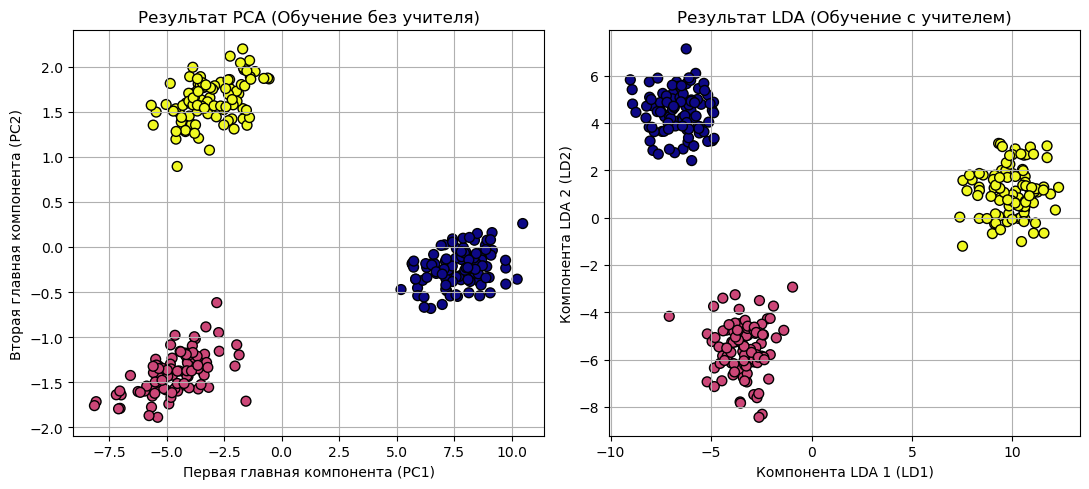

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', edgecolors='black', s=50)
axes[0].set_title("Результат PCA (Обучение без учителя)")
axes[0].set_xlabel("Первая главная компонента (PC1)")
axes[0].set_ylabel("Вторая главная компонента (PC2)")
axes[0].grid(True)

axes[1].scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='plasma', edgecolors='black', s=50)
axes[1].set_title("Результат LDA (Обучение с учителем)")
axes[1].set_xlabel("Компонента LDA 1 (LD1)")
axes[1].set_ylabel("Компонента LDA 2 (LD2)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### 6. Попробуйте изменить параметр degree для полиномиального ядра метода KernelPCA и посмотрите, как это влияет на результат.

In [62]:
degrees = [1, 2, 3, 4]

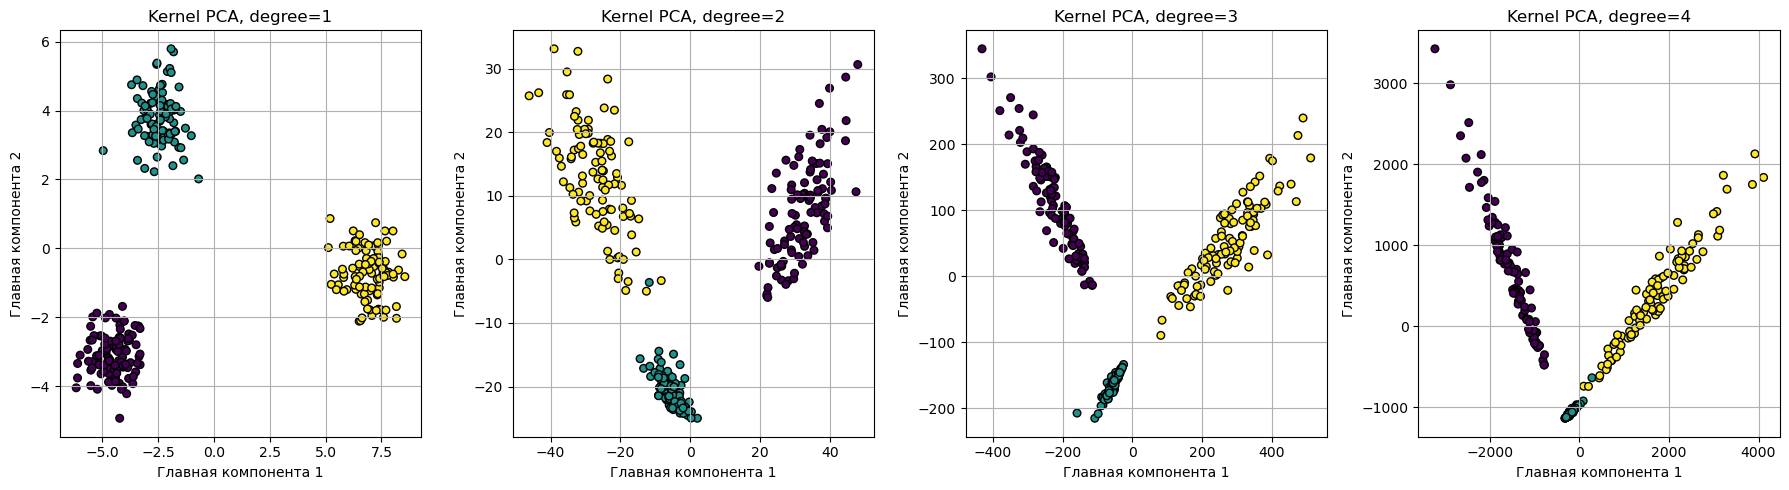

In [63]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, deg in zip(axes, degrees):
    kpca = KernelPCA(n_components=2, kernel='poly', degree=deg)
    X_kpca = kpca.fit_transform(X)

    ax.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis', edgecolors='black', s=30)
    ax.set_title(f"Kernel PCA, degree={deg}")
    ax.set_xlabel("Главная компонента 1")
    ax.set_ylabel("Главная компонента 2")
    ax.grid(True)

plt.tight_layout()
plt.show()

#### 7. Примените все три изученных в этой работе метода к датасету для классификации по вашему выбору.

In [64]:
from sklearn.utils import resample

In [65]:
covtype = fetch_covtype()

X = covtype.data
y = covtype.target

X, y = resample(X, y, n_samples=1000, random_state=42, stratify=y)

In [66]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [67]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

In [68]:
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

In [69]:
tsne = TSNE(n_components=1, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_scaled)

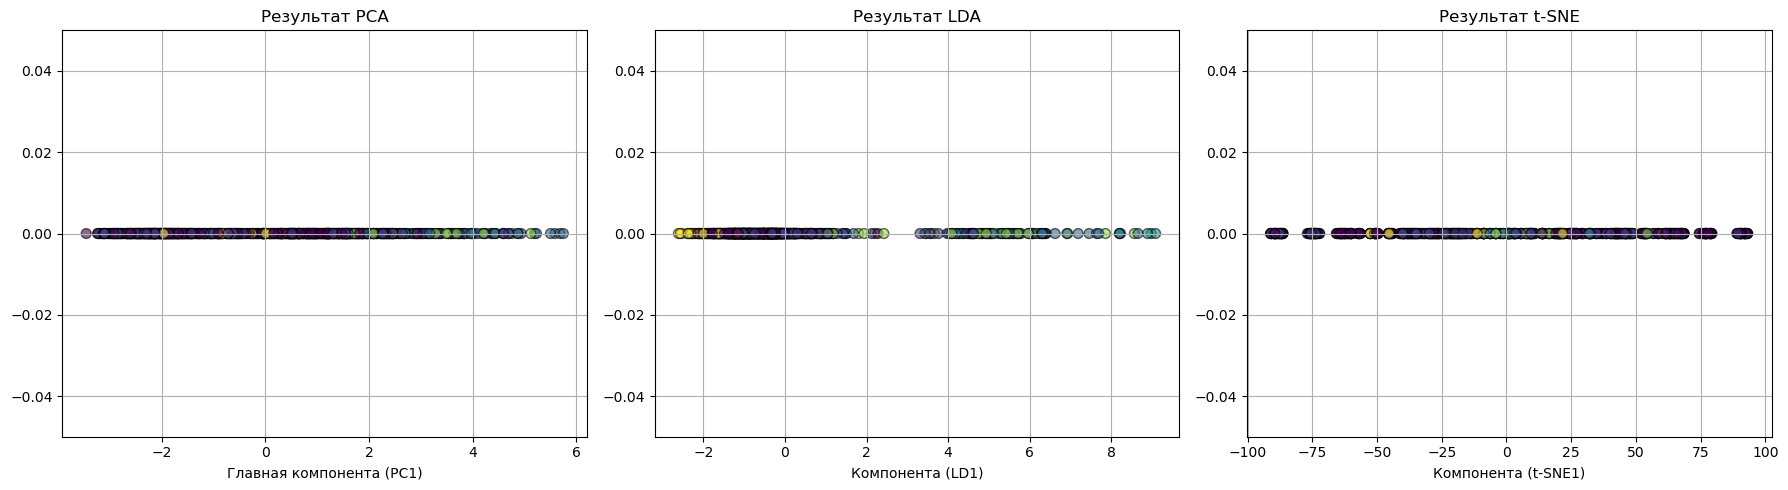

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca, np.zeros_like(X_pca).ravel(), c=y, cmap='viridis', edgecolors='black', s=50, alpha=0.6)
axes[0].set_title("Результат PCA")
axes[0].set_xlabel("Главная компонента (PC1)")
axes[0].set_ylim(-0.05, 0.05)
axes[0].grid(True)

axes[1].scatter(X_lda, np.zeros_like(X_lda).ravel(), c=y, cmap='viridis', edgecolors='black', s=50, alpha=0.6)
axes[1].set_title("Результат LDA")
axes[1].set_xlabel("Компонента (LD1)")
axes[1].set_ylim(-0.05, 0.05)
axes[1].grid(True)

axes[2].scatter(X_tsne, np.zeros_like(X_tsne).ravel(), c=y, cmap='viridis', edgecolors='black', s=50, alpha=0.6)
axes[2].set_title("Результат t-SNE")
axes[2].set_xlabel("Компонента (t-SNE1)")
axes[2].set_ylim(-0.05, 0.05)
axes[2].grid(True)

plt.tight_layout()
plt.show()

#### 8. Исследуйте влияние аргумента perplexity на результат работы алгоритма на многомерных данных.

In [71]:
perplexity_values = [2, 5, 30, 100]

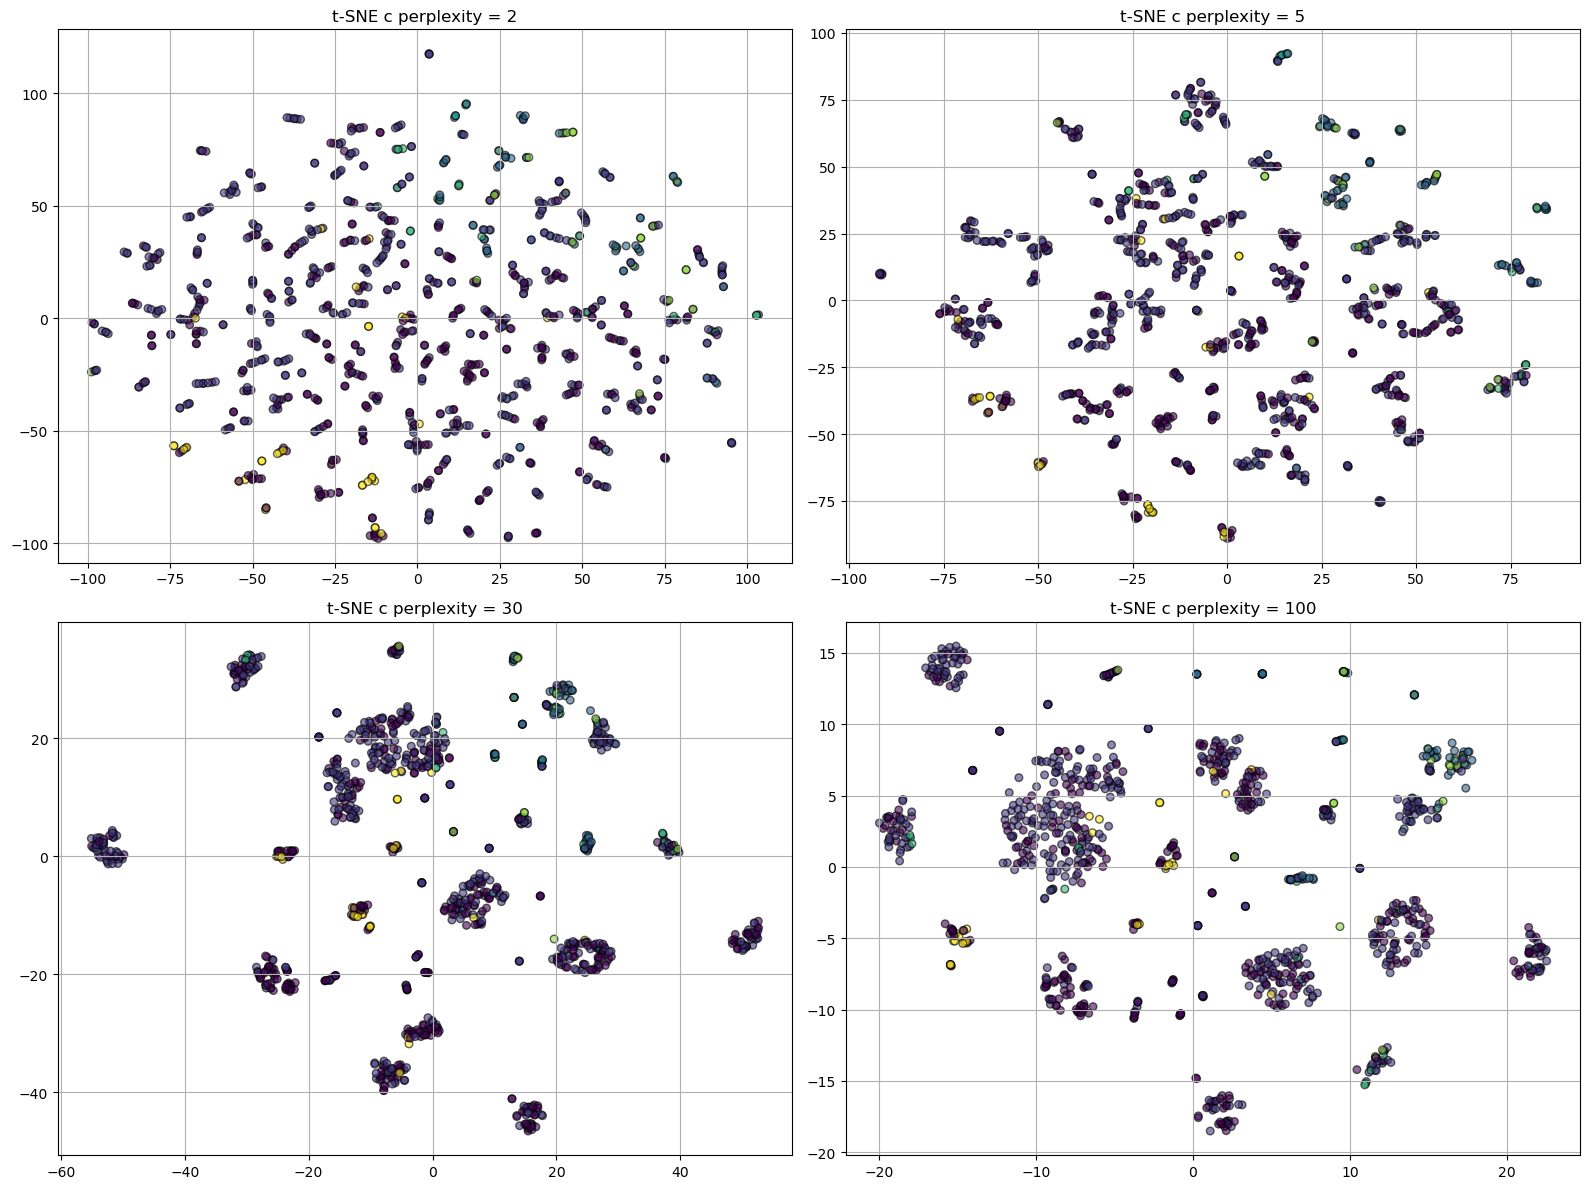

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, perp in enumerate(perplexity_values):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_scaled)

    scatter = axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', edgecolors='black', s=30, alpha=0.6)
    axes[i].set_title(f"t-SNE с perplexity = {perp}")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

#### 9. Визуализируйте выбранный датасет при помощи разных методов понижения размерности.

In [73]:
X_pca = PCA(n_components=2).fit_transform(X_scaled)
X_lda = LDA(n_components=2).fit_transform(X_scaled, y)
X_tsne = TSNE(n_components=2, random_state=42, n_jobs=-1).fit_transform(X_scaled)

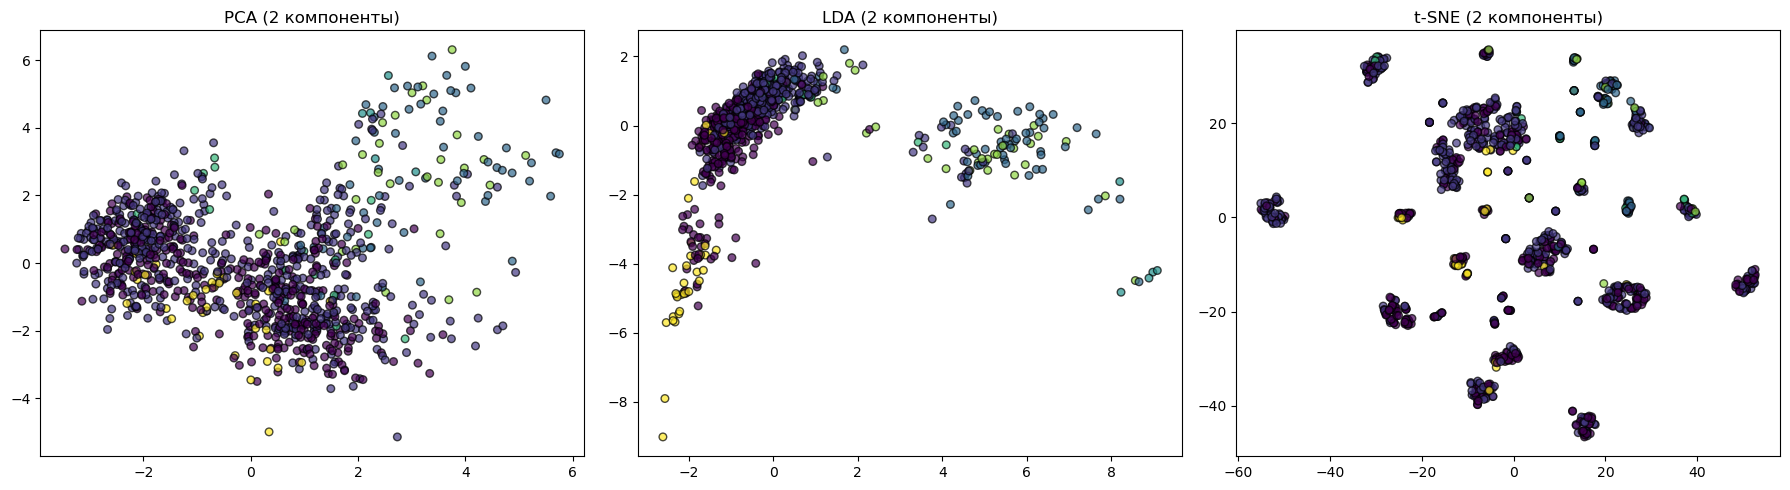

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolors='black', s=30, alpha=0.7)
axes[0].set_title("PCA (2 компоненты)")

axes[1].scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='viridis', edgecolors='black', s=30, alpha=0.7)
axes[1].set_title("LDA (2 компоненты)")

axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', edgecolors='black', s=30, alpha=0.7)
axes[2].set_title("t-SNE (2 компоненты)")

plt.tight_layout()
plt.show()

#### 10. Сравните все три алгоритма классификации по метрике доли объясненной дисперсии. Выберите для каждого метода оптимальное количество кластеров по методу локтя.

In [75]:
pca = PCA().fit(X_scaled)
cum_pca = np.cumsum(pca.explained_variance_ratio_)

In [76]:
lda = LDA().fit(X_scaled, y)
cum_lda = np.cumsum(lda.explained_variance_ratio_)

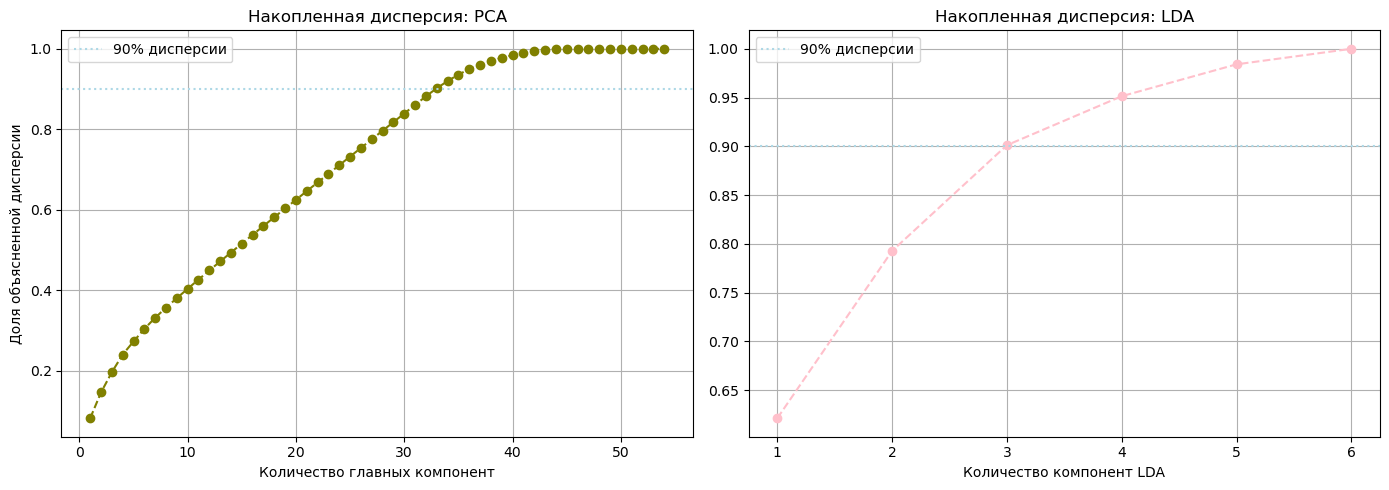

In [77]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(1, len(cum_pca) + 1), cum_pca, marker='o', linestyle='--', color='olive')
ax[0].axhline(y=0.90, color='lightblue', linestyle=':', label='90% дисперсии')
ax[0].set_title('Накопленная дисперсия: PCA')
ax[0].set_xlabel('Количество главных компонент')
ax[0].set_ylabel('Доля объясненной дисперсии')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(range(1, len(cum_lda) + 1), cum_lda, marker='o', linestyle='--', color='pink')
ax[1].axhline(y=0.90, color='lightblue', linestyle=':', label='90% дисперсии')
ax[1].set_title('Накопленная дисперсия: LDA')
ax[1].set_xlabel('Количество компонент LDA')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

In [78]:
X_pca_2d = PCA(n_components=2).fit_transform(X_scaled)
X_lda_2d = LDA(n_components=2).fit_transform(X_scaled, y)
X_tsne_2d = TSNE(n_components=2, random_state=42, n_jobs=-1).fit_transform(X_scaled)

In [79]:
datasets = {'PCA': X_pca_2d, 'LDA': X_lda_2d, 't-SNE': X_tsne_2d}
K = range(1, 9)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

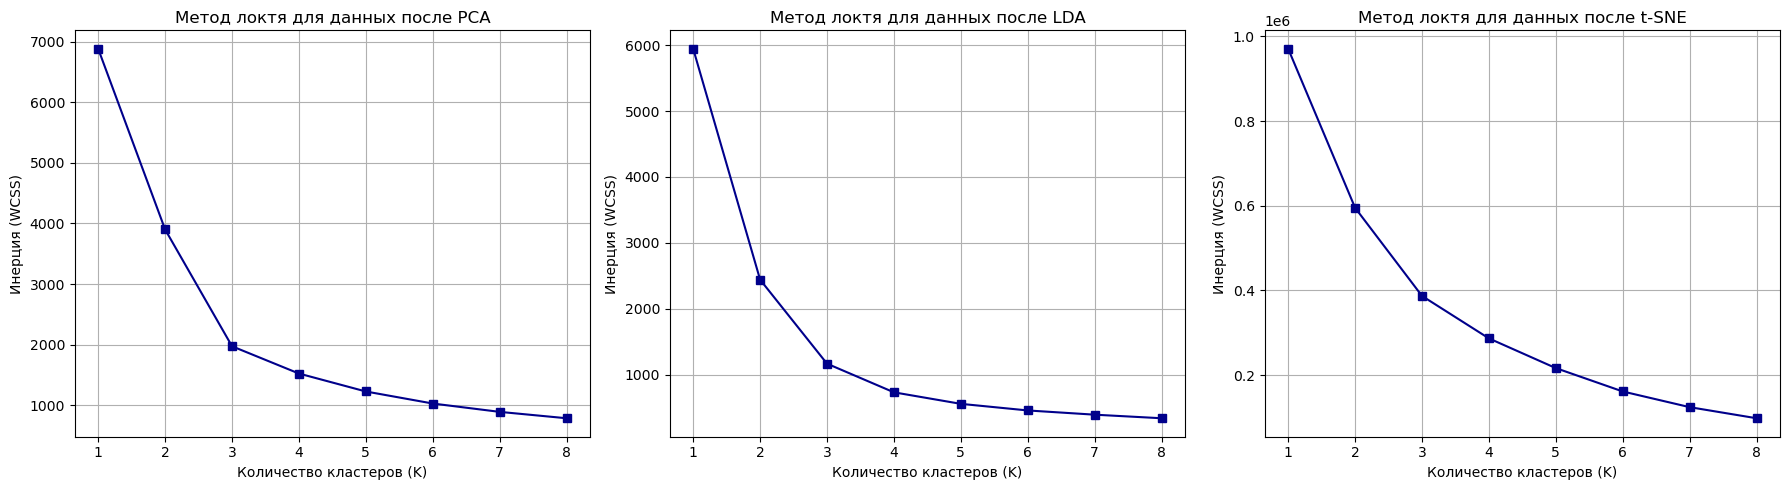

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, data) in enumerate(datasets.items()):
    inertia = []
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertia.append(kmeans.inertia_) # сумма квадратов расстояний до центроидов

    axes[i].plot(K, inertia, marker='s', color='darkblue', linestyle='-')
    axes[i].set_title(f"Метод локтя для данных после {name}")
    axes[i].set_xlabel("Количество кластеров (K)")
    axes[i].set_ylabel("Инерция (WCSS)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

#### 11. Повторите измерение метрики, но уже после разбиения выборки на тестовую и обучающую. Сравните долю объясненной дисперсии на тестовой выборке.

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [84]:
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [85]:
lda = LDA()

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

In [86]:
pca_train_var = pca.explained_variance_ratio_
pca_test_var = np.var(X_test_scaled, axis=0)/ np.sum(np.var(X_test_scaled, axis=0)) #дисперсия= дисп каждой компоненты/дисп исходного x_test

In [87]:
lda_train_var = lda.explained_variance_ratio_
lda_test_var = np.var(X_test_scaled, axis=0)/ np.sum(np.var(X_test_scaled, axis=0))

Кумулятивная дисперсия

In [88]:
cum_pca_train = np.cumsum(pca_train_var)
cum_pca_test = np.cumsum(pca_test_var)
cum_lda_train = np.cumsum(lda_train_var)
cum_lda_test = np.cumsum(lda_test_var)

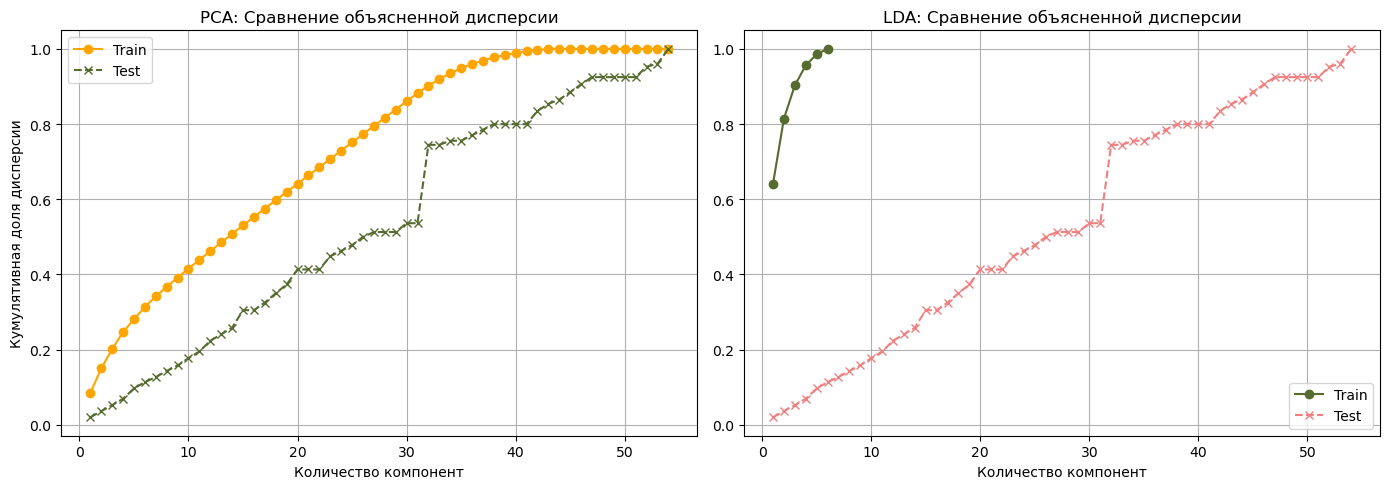

In [89]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(1, len(cum_pca_train) + 1), cum_pca_train, marker='o', label='Train', color='orange')
ax[0].plot(range(1, len(cum_pca_test) + 1), cum_pca_test, marker='x', linestyle='--', label='Test', color='darkolivegreen')
ax[0].set_title('PCA: Сравнение объясненной дисперсии')
ax[0].set_xlabel('Количество компонент')
ax[0].set_ylabel('Кумулятивная доля дисперсии')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(range(1, len(cum_lda_train) + 1), cum_lda_train, marker='o', label='Train', color='darkolivegreen')
ax[1].plot(range(1, len(cum_lda_test) + 1), cum_lda_test, marker='x', linestyle='--', label='Test', color='lightcoral')
ax[1].set_title('LDA: Сравнение объясненной дисперсии')
ax[1].set_xlabel('Количество компонент')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()